<a href="https://colab.research.google.com/github/benjaminpilnick/stat362/blob/main/hw2_nlp_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

This notebook demonstrates various approaches to financial sentiment analysis using the Financial PhraseBank dataset. We explore multiple machine learning and deep learning techniques, progressing from basic to advanced methods:

1. Traditional ML with embeddings
   - Multi-layer Perceptron (MLP)
   - XGBoost (Gradient Boosting)

2. Sequential Models
   - Gated Recurrent Unit
   - Bidirectional Gated RNNs
   - Transformer Architecture

3. Modern Approaches
   - Pre-trained FinBERT

Each section includes implementation, evaluation metrics, and performance comparison. By the end of this notebook, you'll understand the trade-offs between different approaches to sentiment analysis.

## Setup and Requirements

This notebook requires the following packages:

- transformers (4.30+)
- datasets (2.10+)
- nltk (3.8+)
- xgboost (2.0+)
- sentence_transformers (2.2+)
- keras (3.0+)
- torch (2.0+)

We'll first set up our environment and configure the backend (TensorFlow or PyTorch) based on the operating system.

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


from transformers import AutoTokenizer, AutoModel, BertTokenizerFast, BertModel, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
import xgboost as xgb

import datasets
import keras
import torch
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')

In [ ]:
import platform
import os

# Check operating system
is_macos = platform.system() == 'Darwin'

if is_macos:
    # For MacOS, use TensorFlow backend
    os.environ['KERAS_BACKEND'] = 'tensorflow'
    import tensorflow as tf
    print("Using TensorFlow backend on MacOS")
    device = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
else:
    # For other OS, use PyTorch backend
    os.environ['KERAS_BACKEND'] = 'torch'
    import torch
    print("Using PyTorch backend")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {device}")

Using PyTorch backend
Using device: cuda


## Dataset Description

The Financial PhraseBank dataset is a comprehensive collection of financial texts with sentiment annotations:

- **Size**: 4,840 sentences from English financial news articles
- **Labels**: Three-class sentiment classification (positive, negative, neutral)
- **Annotation**: 5-8 annotators per sentence with varying agreement levels
- **Source**: News articles about OMX Helsinki-listed companies
- **Annotators**: Finance experts (researchers and master's students from Aalto University)

### Importance
The dataset addresses the scarcity of high-quality annotated data in financial sentiment analysis, providing a benchmark for model evaluation. The annotations are particularly valuable as they come from individuals with domain expertise in finance.

### Dataset Variants
The dataset offers different versions based on annotator agreement:
- 50% agreement (used in this notebook)
- 66% agreement
- 75% agreement
- 100% agreement


### Data Loading, Inspection, and Preprocessing


Loading Financial PhraseBank dataset from Hugging Face...
Dataset Shape: (4846, 3)

Sample entries:


,text,label,sentiment
0,"According to Gran , the company has no plans t...",1,neutral
1,Technopolis plans to develop in stages an area...,1,neutral
2,The international electronic industry company ...,0,negative
3,With the new production plant the company woul...,2,positive
4,According to the company 's updated strategy f...,2,positive



Sentiment Distribution:
sentiment
neutral     0.594
positive    0.281
negative    0.125
Name: proportion, dtype: float64


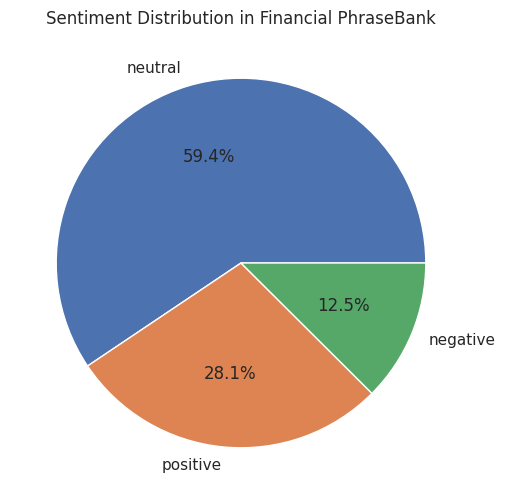

In [ ]:
# Load and preprocess the dataset
def load_financial_phrasebank():
    """
    Load and preprocess the Financial PhraseBank dataset from Hugging Face.

    Returns:
        pd.DataFrame: Processed dataset with text and sentiment columns
    """
    # Load dataset from Hugging Face
    data = pd.read_csv("/content/financial_phrasebank_50agree.csv")

    # Convert to pandas DataFrame


    # Map numerical labels to text labels
    data['sentiment'] = data['label'].map({0: 'negative', 1: 'neutral', 2: 'positive'})

    # Rename sentence column to text for consistency
    data = data.rename(columns={'sentence': 'text'})

    # Display basic information about the dataset
    print("Dataset Shape:", data.shape)
    print("\nSample entries:")
    display(data.head())

    # Show class distribution
    print("\nSentiment Distribution:")
    sentiment_dist = data['sentiment'].value_counts(normalize=True)
    print(sentiment_dist.round(3))

    # Create a pie chart of sentiment distribution
    plt.figure(figsize=(10, 6))
    plt.pie(sentiment_dist.values, labels=sentiment_dist.index, autopct='%1.1f%%')
    plt.title('Sentiment Distribution in Financial PhraseBank')
    plt.show()

    return data

# Load the dataset
print("Loading Financial PhraseBank dataset from Hugging Face...")
data = load_financial_phrasebank()

### Data Splitting

The dataset doesn't come with a predefined train/validation/test split, so we'll create our own using an 80/10/10 split ratio.

In [ ]:
# Create train/validation/test splits
from sklearn.preprocessing import LabelEncoder

def prepare_data_splits(data, test_size=0.2, val_size=0.25, random_state=42):
    """
    Prepare data splits and encode labels.

    Args:
        data (pd.DataFrame): Input dataset
        test_size (float): Proportion of data for testing
        val_size (float): Proportion of training data for validation
        random_state (int): Random seed for reproducibility

    Returns:
        tuple: (X_train, X_val, X_test, y_train, y_val, y_test)
    """
    # Encode labels
    le = LabelEncoder()
    y = le.fit_transform(data['sentiment'])

    # First split: training + validation vs test
    X_temp, X_test, y_temp, y_test = train_test_split(
        data['text'].values,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Second split: training vs validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=val_size,
        random_state=random_state,
        stratify=y_temp
    )

    print("Data split sizes:")
    print(f"Training: {len(X_train)} samples")
    print(f"Validation: {len(X_val)} samples")
    print(f"Test: {len(X_test)} samples")

    return X_train, X_val, X_test, y_train, y_val, y_test

# Create data splits
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_splits(data)

Data split sizes:
Training: 2907 samples
Validation: 969 samples
Test: 970 samples


## Data Modeling

To address the sentiment analysis task using machine learning, we employ modern approaches that leverage **text embeddings** — a cornerstone technique in deep learning–based natural language processing.

In this notebook, we explore three complementary modeling directions:

1. **Sentence-level embeddings**  
   Each sentence is encoded into a fixed-size vector (e.g., 384 dimensions).  
   These embeddings are used as input features for traditional machine learning classifiers such as **MLP** and **XGBoost**.

2. **Token-level embeddings with sequence models**  
   Texts are tokenized into individual tokens, each represented as an embedding vector forming a sequence.  
   Sequence models such as **RNN-based architectures** and **Transformers** are then employed to capture temporal and contextual dependencies within the text.

3. **Pretrained sentiment models (inference only)**  
   We also apply **pretrained sentiment analysis models**, such as **FinBERT**, directly to the test data without additional training.  
   This approach allows us to benchmark performance against state-of-the-art, domain-specific models trained on large financial text corpora.



### Sentence and Word Embeddings Using SentenceTransformers

[**SentenceTransformers**](https://www.sbert.net/) is a powerful library that provides state-of-the-art pretrained models for generating text embeddings.  
In this section, we use it for two complementary purposes:

1. **Sentence-level embeddings**  
   - Convert each full sentence into a fixed-length vector (384 dimensions).  
   - Capture the semantic meaning of complete financial statements.  
   - Serve as input features for traditional machine learning models such as **XGBoost** and **MLP**.

2. **Word-level embeddings**  
   - Generate embeddings for individual tokens within each sentence.  
   - Preserve sequential and contextual information for deep learning models.  
   - Used as input for **GRU**, **LSTM**, and **Transformer** architectures.

#### Model Details
- **Base model:** `all-MiniLM-L6-v2`  
- **Embedding dimension:** 384  
- **Advantages:**  
  - Fast inference time  
  - Strong semantic performance on financial text  
  - Memory efficient and lightweight

These embeddings form the **foundation for all classification models** developed in this notebook.  
Next, we'll load the SentenceTransformer model and ensure it runs on the appropriate compute device (CPU or GPU).


In [ ]:
# Load SentenceTransformer model with appropriate device placement
try:
    from sentence_transformers import SentenceTransformer
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

    # Handle device placement based on backend
    if is_macos:
        with tf.device(device):
            model = embedding_model
    else:
        model = embedding_model.to(device)

    print("Embedding model loaded successfully")
except Exception as e:
    print(f"Error loading embedding model: {e}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully


### Traditional Models with Sentence-Level Embeddings

In this section, we implement and evaluate **traditional machine learning models** using the generated sentence embeddings.

#### Generating Sentence Embeddings

In [ ]:
# Generate sentence embeddings for train, validation, and test sets
print("Generating sentence embeddings for all splits...")

# Generate embeddings for each split
X_train_emb = embedding_model.encode(
    X_train,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_val_emb = embedding_model.encode(
    X_val,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_test_emb = embedding_model.encode(
    X_test,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("\nEmbedding shapes:")
print(f"Training: {X_train_emb.shape}")
print(f"Validation: {X_val_emb.shape}")
print(f"Test: {X_test_emb.shape}")
print(f"\nEach sentence is represented by a {X_train_emb.shape[1]}-dimensional vector")

Generating sentence embeddings for all splits...


Batches:   0%|          | 0/91 [00:00<?, ?it/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]


Embedding shapes:
Training: (2907, 384)
Validation: (969, 384)
Test: (970, 384)

Each sentence is represented by a 384-dimensional vector


Let's visualize the sentence embeddings using **t-SNE**, a dimensionality reduction technique for visualization that you'll learn in the **Unsupervised Learning** module.


Reducing dimensionality with t-SNE...


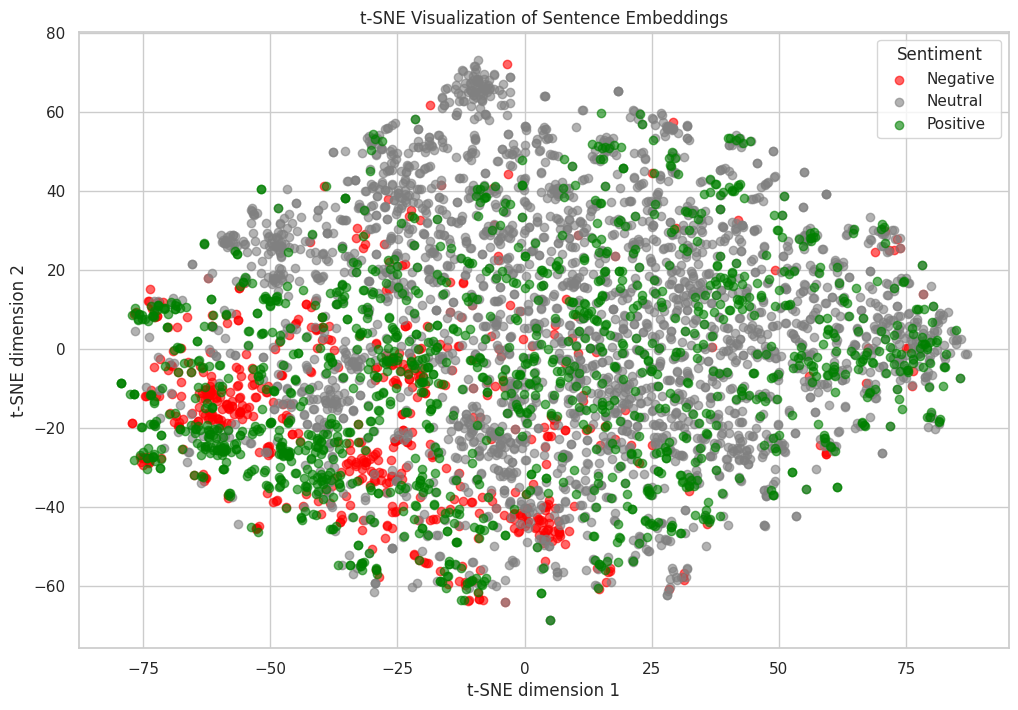

In [ ]:
# Visualize embeddings using t-SNE
from sklearn.manifold import TSNE

# Combine embeddings and labels for visualization
all_embeddings = np.vstack([X_train_emb, X_val_emb, X_test_emb])
all_labels = np.concatenate([y_train, y_val, y_test])

# Reduce dimensionality to 2D using t-SNE
print("Reducing dimensionality with t-SNE...")
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Create scatter plot with discrete colors
plt.figure(figsize=(12, 8))

# Define colors and labels for each sentiment
colors = ['red', 'gray', 'green']
sentiments = ['Negative', 'Neutral', 'Positive']

for i, (color, sentiment) in enumerate(zip(colors, sentiments)):
    mask = all_labels == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=color, label=sentiment, alpha=0.6)

plt.title('t-SNE Visualization of Sentence Embeddings')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.legend(title='Sentiment')
plt.grid(True)
plt.show()


### Task 1: MLP for sentiment classification

Construct a feed-forward neural network that achieves a test accuracy of at least 74.5%

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# 1. Instantiate a Sequential model
mlp_model = Sequential()
mlp_model.add(Dense(128, activation='relu', input_shape=(X_train_emb.shape[1],)))
mlp_model.add(Dropout(0.3))
mlp_model.add(Dense(64, activation='relu'))
mlp_model.add(Dense(3, activation='softmax'))

# 7. Compile the model
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("MLP Model Summary:")
mlp_model.summary()

# 8. Define an EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 9. Train the model
print("\nTraining MLP model...")
history_mlp = mlp_model.fit(
    X_train_emb,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_emb, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("MLP model training complete.")

MLP Model Summary:


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP model...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6008 - loss: 0.9208 - val_accuracy: 0.7296 - val_loss: 0.6578
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7445 - loss: 0.6048 - val_accuracy: 0.7606 - val_loss: 0.5543
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7997 - loss: 0.4731 - val_accuracy: 0.7637 - val_loss: 0.5414
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8356 - loss: 0.4198 - val_accuracy: 0.7688 - val_loss: 0.5417
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8298 - loss: 0.4074 - val_accuracy: 0.7781 - val_loss: 0.5480
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8631 - loss: 0.3466 - val_accuracy: 0.7595 - val_loss: 0.5743
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8816 - loss: 0.3072 - val_accuracy: 0.7833 - val_loss: 0.5658
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9076 - loss: 0.2644 - val_accu

In [ ]:
#Now evaluate on the test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = mlp_model.evaluate(X_test_emb, y_test, verbose=0)
print(
    f"Test Loss: {test_loss:.4f}\n"
    f"Test Accuracy: {test_accuracy:.4f}"
)



Evaluating on test set...
Test Loss: 0.5479
Test Accuracy: 0.7711


### Task 2: Gradient Boosted Trees for Multiclass Classification

Explore optimized gradient boosting algorithms — **XGBoost**, **LightGBM**, or **CatBoost** — to build a model that achieves performance comparable to the **MLP** model.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# XGB classifier
xgb_model = XGBClassifier(
    objective='multi:softmax',  # For multiclass classification with direct class labels
    num_class=3,                # Number of unique classes
    eval_metric='mlogloss',     # Evaluation metric for multiclass logloss
    use_label_encoder=False,    # Suppress deprecation warning
    random_state=42             # For reproducibility
)
#Note we are using the base numebrs for depth, learning rate, n_estimators

#Training the model
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_emb, y_train)
print("XGBoost model training complete.")

# Predictions
y_pred_xgb = xgb_model.predict(X_test_emb)

#Evaluation of the model
print("\nEvaluating XGBoost model on the test set:")
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Test Accuracy: {accuracy_xgb:.4f}")

#Getting the labels and the classifcation report
sentiment_labels = ['negative', 'neutral', 'positive']
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=sentiment_labels))


Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:57:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete.

Evaluating XGBoost model on the test set:
Test Accuracy: 0.7557

Classification Report for XGBoost:
              precision    recall  f1-score   support

    negative       0.73      0.61      0.67       121
     neutral       0.77      0.90      0.83       576
    positive       0.71      0.51      0.59       273

    accuracy                           0.76       970
   macro avg       0.74      0.67      0.70       970
weighted avg       0.75      0.76      0.74       970



### Sequential Models with Word-Level Embeddings

Unlike traditional machine learning approaches that use fixed sentence embeddings, sequential models process text as a **sequence of words**, preserving word order and contextual relationships.  
In this section, we implement three powerful sequential architectures:

1. **Gated RNNs**  
   - A variant of the vanilla RNN  
   - Efficient for processing sequential data  
   - Effective at capturing short-term dependencies  

2. **Bidirectional Gated RNNs**  
   - Process sequences in both forward and backward directions  
   - Capture both past and future context  
   - Well-suited for natural language understanding tasks  

3. **Transformer** *(implemented for you)*  
   - Employs a self-attention mechanism  
   - Enables parallel processing of sequences  
   - Achieves state-of-the-art performance on modern NLP tasks
`


#### Text Preprocessing for Sequential Models

To prepare text data for sequential models, we need to:

1. **Tokenization**
   - Break sentences into individual words/tokens
   - Preserve meaningful linguistic units
   - Handle special characters and punctuation

2. **Sequence Padding**
   - Ensure all sequences have same length
   - Pad shorter sequences with zeros
   - Truncate longer sequences to max length

3. **Word-Level Embeddings**
   - Convert each token to fixed-size vector
   - Capture semantic relationships between words
   - Use pre-trained embeddings for better representation

We'll use NLTK's tokenizer for word segmentation and then create fixed-length sequences suitable for our models.

In [ ]:
import nltk
nltk.download('punkt_tab')  # Download the necessary data for tokenization
from nltk.tokenize import word_tokenize
word_tokenize('hello world!')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['hello', 'world', '!']

Check the sentence length distribution

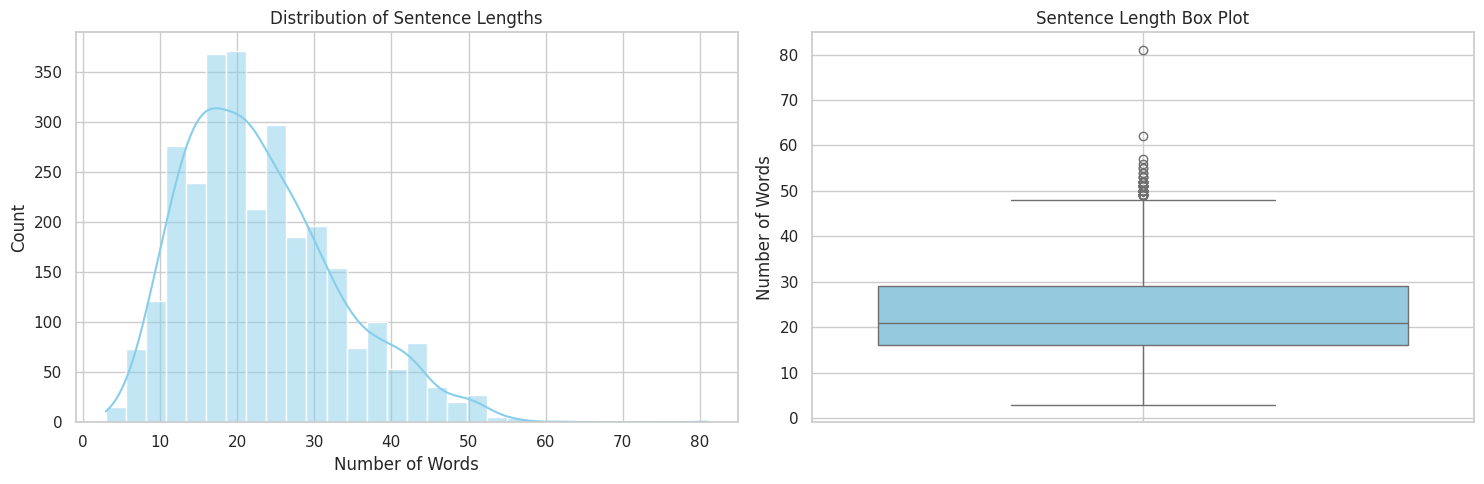


Sentence Length Statistics:
Minimum length: 3 words
Maximum length: 81 words
Mean length: 23.0 words
Median length: 21 words

Percentiles:
10th percentile: 12.0 words
25th percentile: 16.0 words
75th percentile: 29.0 words
90th percentile: 37.0 words
95th percentile: 42.0 words

Sentences longer than 30 words: 611 (21.0%)

Sentences longer than 40 words: 194 (6.7%)

Sentences longer than 50 words: 27 (0.9%)

Sentences longer than 60 words: 2 (0.1%)


In [ ]:
# Analyze sentence length distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate sentence lengths using the tokenized text
sentence_lengths = [len(word_tokenize(text)) for text in X_train]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Histogram with KDE
sns.histplot(sentence_lengths, bins=30, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Distribution of Sentence Lengths')
ax1.set_xlabel('Number of Words')
ax1.set_ylabel('Count')
ax1.grid(True)

# Plot 2: Box plot
sns.boxplot(y=sentence_lengths, color='skyblue', ax=ax2)
ax2.set_title('Sentence Length Box Plot')
ax2.set_ylabel('Number of Words')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print statistical summary
print("\nSentence Length Statistics:")
print(f"Minimum length: {min(sentence_lengths)} words")
print(f"Maximum length: {max(sentence_lengths)} words")
print(f"Mean length: {sum(sentence_lengths)/len(sentence_lengths):.1f} words")
print(f"Median length: {sorted(sentence_lengths)[len(sentence_lengths)//2]} words")
print(f"\nPercentiles:")
for p in [10, 25, 75, 90, 95]:
    percentile = np.percentile(sentence_lengths, p)
    print(f"{p}th percentile: {percentile:.1f} words")

# Calculate how many sentences would be affected by different max lengths
for max_len in [30, 40, 50, 60]:
    affected = sum(1 for x in sentence_lengths if x > max_len)
    print(f"\nSentences longer than {max_len} words: {affected} ({affected/len(sentence_lengths):.1%})")

sentence different length, we need to pad them to make them the same length

In [ ]:
# Tokenization and padding function for sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def process_text_sequences(texts, max_length=50, padding='post', truncating='post'):
    """
    Convert texts to padded sequences of tokens.

    Args:
        texts: List of text strings
        max_length: Maximum sequence length (default: 50)
        padding: 'pre' or 'post' padding (default: 'post')
        truncating: 'pre' or 'post' truncation (default: 'post')

    Returns:
        List of padded token sequences
    """
    # Tokenize all texts
    sequences = [word_tokenize(text) for text in texts]

    # Convert tokens to numpy arrays with padding
    padded_sequences = pad_sequences(
        sequences=[s[:max_length] for s in sequences],  # Truncate if needed
        maxlen=max_length,
        padding=padding,
        truncating=truncating,
        dtype=object,  # Use object dtype for string tokens
        value=''  # Use empty string as padding token
    )

    return padded_sequences

# Process training, validation, and test sets
print("Processing sequences...")
X_train_padded = process_text_sequences(X_train)
X_val_padded = process_text_sequences(X_val)
X_test_padded = process_text_sequences(X_test)

# Print shapes and example
print(f"\nSequence shapes:")
print(f"Training: {X_train_padded.shape}")
print(f"Validation: {X_val_padded.shape}")
print(f"Test: {X_test_padded.shape}")

# Show an example sequence
print("\nExample padded sequence:")
print(X_train_padded[0])

Processing sequences...

Sequence shapes:
Training: (2907, 50)
Validation: (969, 50)
Test: (970, 50)

Example padded sequence:
['Finnish' 'electronics' 'contract' 'manufacturer' 'Scanfil' 'had' 'net'
 'sales' 'of' 'EUR' '52.2' 'mn' 'in' 'the' 'first' 'quarter' 'of' '2007'
 ',' 'down' 'from' 'EUR' '60.1' 'mn' 'a' 'year' 'before' '.' '' '' '' ''
 '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '']


In [ ]:
from functools import cache
@cache
def encode_words(text):
    return embedding_model.encode(text)

In [ ]:
%%time
# Convert padded sequences to embeddings
def create_embedding_sequences(sequences, max_length=50):
    """
    Convert sequences of words to sequences of embeddings using cached word vectors.
    Ensures all sequences have the same length through padding.

    Args:
        sequences: List of word sequences (padded)
        max_length: Maximum sequence length (default: 50)
    Returns:
        numpy array of shape (n_sequences, max_length, embedding_dim)
    """
    n_sequences = len(sequences)
    embedding_dim = 384  # Known dimension from the model

    # Initialize the output array with zeros
    embedded_seqs = np.zeros((n_sequences, max_length, embedding_dim))

    for i, seq in enumerate(sequences):
        # Get embeddings for non-empty tokens
        valid_tokens = [word for word in seq if word != '']
        # Truncate if necessary
        valid_tokens = valid_tokens[:max_length]
        # Create embeddings for valid tokens
        seq_embeddings = [encode_words(word) for word in valid_tokens]

        # Add embeddings to the output array with padding
        for j, embedding in enumerate(seq_embeddings):
            if j < max_length:
                embedded_seqs[i, j] = embedding

    return embedded_seqs

# Create embeddings for each split
print("Creating word embeddings for training set...")
X_train_embedded = create_embedding_sequences(X_train_padded)
print("Creating word embeddings for validation set...")
X_val_embedded = create_embedding_sequences(X_val_padded)
print("Creating word embeddings for test set...")
X_test_embedded = create_embedding_sequences(X_test_padded)

print("\nEmbedding shapes:")
print(f"Training: {X_train_embedded.shape}")
print(f"Validation: {X_val_embedded.shape}")
print(f"Test: {X_test_embedded.shape}")

Creating word embeddings for training set...
Creating word embeddings for validation set...
Creating word embeddings for test set...

Embedding shapes:
Training: (2907, 50, 384)
Validation: (969, 50, 384)
Test: (970, 50, 384)
CPU times: user 1min 16s, sys: 222 ms, total: 1min 16s
Wall time: 1min 24s


### Task 3: Build a Gated RNN Model (LSTM or GRU) to Achieve Test Accuracy Above 75%

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define the GRU model
model = Sequential([
    GRU(128, return_sequences=False, input_shape = (X_train_embedded.shape[1], X_train_embedded.shape[2])),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')])


# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("GRU Model Summary:")
model.summary()

# Define EarlyStopping callback
early_stopping_gru = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the GRU model
print("\nTraining GRU model...")
history_gru =model.fit(
    X_train_embedded,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val_embedded, y_val),
    callbacks=[early_stopping_gru],
    verbose=1
)

print("GRU model training complete.")

# Evaluate the GRU model on the test set
print("\nEvaluating GRU model on the test set...")
loss_gru, accuracy_gru = model.evaluate(X_test_embedded, y_test, verbose=0)
print(f"Test Loss: {loss_gru:.4f}")
print(f"Test Accuracy: {accuracy_gru:.4f}")

# Make predictions
y_pred_gru = np.argmax(model.predict(X_test_embedded), axis=-1)



GRU Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 128)            │       197,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,827 (804.01 KB)

 Trainable params: 205,827 (804.01 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU model...
Epoch 1/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5723 - loss: 0.9989 - val_accuracy: 0.5934 - val_loss: 0.9298
Epoch 2/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5976 - loss: 0.9324 - val_accuracy: 0.5944 - val_loss: 0.9333
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5948 - loss: 0.9344 - val_accuracy: 0.5955 - val_loss: 0.9081
Epoch 4/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.6089 - loss: 0.9195 - val_accuracy: 0.6316 - val_loss: 0.8565
Epoch 5/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6137 - loss: 0.8991 - val_accuracy: 0.6326 - val_loss: 0.8616
Epoch 6/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6386 - loss: 0.8566 - val_accuracy: 0.6305 - val_loss: 0.8376
Epoch 7/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6765 - loss: 0.8071 - val_accuracy: 0.6563 - val_loss: 0.8363
Epoch 8/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6615 - loss: 0.

### Task 4: Build a Bidirectional Gated RNN Model to Achieve Test Accuracy Above 76%


Bidirectional GRU Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_5 (Bidirectional) │ (None, 256)            │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,395 (1.57 MB)

 Trainable params: 411,395 (1.57 MB)

 Non-trainable params: 0 (0.00 B)


Training Bidirectional GRU model...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.5713 - loss: 0.9641 - val_accuracy: 0.6037 - val_loss: 0.8830
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6122 - loss: 0.8736 - val_accuracy: 0.6305 - val_loss: 0.8090
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.6627 - loss: 0.7882 - val_accuracy: 0.6563 - val_loss: 0.7764
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.6786 - loss: 0.7420 - val_accuracy: 0.6698 - val_loss: 0.7416
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6869 - loss: 0.7241 - val_accuracy: 0.6821 - val_loss: 0.7282
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.6854 - loss: 0.6720 - val_accuracy: 0.6997 - val_loss: 0.7183
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7326 - loss: 0.6453 - val_accuracy: 0.7193 - val_loss: 0.7980
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7649 - lo

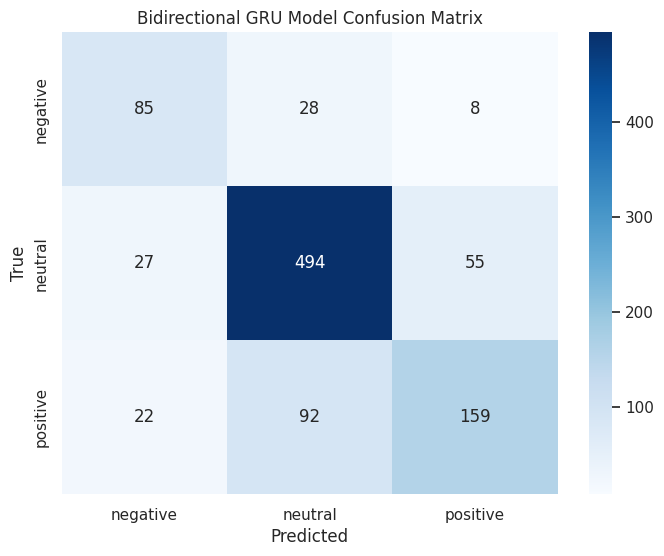

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define the Bidirectional GRU model
def build_bidirectional_gru_model(input_shape, num_classes):
    model = Sequential([
        Bidirectional(GRU(128, return_sequences=False), input_shape=input_shape),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Input shape will be (max_length, embedding_dim) for Bidirectional GRU
input_shape = (X_train_embedded.shape[1], X_train_embedded.shape[2])
num_classes = 3 # Negative, Neutral, Positive

bidirectional_gru_model = build_bidirectional_gru_model(input_shape, num_classes)

# Compile the model
bidirectional_gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("Bidirectional GRU Model Summary:")
bidirectional_gru_model.summary()

# Define EarlyStopping callback
early_stopping_bgru = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the Bidirectional GRU model
print("\nTraining Bidirectional GRU model...")
history_bgru = bidirectional_gru_model.fit(
    X_train_embedded,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_embedded, y_val),
    callbacks=[early_stopping_bgru],
    verbose=1
)

print("Bidirectional GRU model training complete.")

# Evaluate the Bidirectional GRU model on the test set
print("\nEvaluating Bidirectional GRU model on the test set...")
loss_bgru, accuracy_bgru = bidirectional_gru_model.evaluate(X_test_embedded, y_test, verbose=0)
print(f"Test Loss: {loss_bgru:.4f}")
print(f"Test Accuracy: {accuracy_bgru:.4f}")

# Make predictions
y_pred_bgru = np.argmax(bidirectional_gru_model.predict(X_test_embedded), axis=-1)

# Generate classification report
sentiment_labels = ['negative', 'neutral', 'positive']
print("\nClassification Report for Bidirectional GRU Model:")
print(classification_report(y_test, y_pred_bgru, target_names=sentiment_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_bgru = confusion_matrix(y_test, y_pred_bgru)
sns.heatmap(cm_bgru, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('Bidirectional GRU Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
X_train_embedded.shape

(2907, 50, 384)

At this point, you’ve completed all your assigned tasks.  
To give you a taste of **state-of-the-art models and large language models (LLMs)**, the **Transformer** and **pretrained models** have been implemented for you — you only need to run the provided code.  

🎉 **Congratulations on reaching this stage!**



### Transformer Model for Sentiment Analysis

The Transformer architecture, introduced in the paper *“Attention Is All You Need”* (2017), represents a major breakthrough in deep learning for natural language processing tasks.  
Unlike RNN-based models (LSTM or GRU), Transformers process entire sequences in parallel using self-attention mechanisms.

For this particular problem, however, a Transformer is somewhat **overkill**, as the dataset is relatively small and the task can be solved effectively with simpler models.


In [ ]:
# Import required layers for transformer
from keras.layers import MultiHeadAttention, LayerNormalization, Dropout, Input, GlobalAveragePooling1D, Add, Dense
from keras.models import Model
import numpy as np

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head self attention with residual connection
    attention_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout
    )(inputs, inputs)
    attention_output = Dropout(dropout)(attention_output)
    attention_output = Add()([inputs, attention_output])  # Residual connection
    x1 = LayerNormalization(epsilon=1e-6)(attention_output)

    # Feed-forward network with residual connection
    ffn_output = Dense(ff_dim, activation="relu")(x1)
    ffn_output = Dense(inputs.shape[-1])(ffn_output)
    ffn_output = Dropout(dropout)(ffn_output)
    x2 = Add()([x1, ffn_output])  # Residual connection
    return LayerNormalization(epsilon=1e-6)(x2)

# Build the transformer model
def build_transformer_model(
    max_seq_length=50,
    embed_dim=384,
    num_heads=4,  # Reduced from 8 to better match embedding dimension
    ff_dim=512,   # Increased feed-forward dimension
    num_transformer_blocks=2,
    mlp_units=[256, 128],  # Increased MLP units
    dropout=0.1,
    mlp_dropout=0.1,
):
    inputs = Input(shape=(max_seq_length, embed_dim))
    x = inputs

    # Add positional encoding if needed (not required if using pre-trained embeddings)
    # x = positional_encoding(x)

    # Transformer blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, embed_dim // num_heads, num_heads, ff_dim, dropout)

    # Global average pooling
    x = GlobalAveragePooling1D()(x)

    # MLP layers with residual connections
    for dim in mlp_units:
        x_residual = x
        x = Dense(dim, activation="relu")(x)
        x = Dropout(mlp_dropout)(x)
        if x_residual.shape[-1] == dim:  # Only add if dimensions match
            x = Add()([x, x_residual])
        x = LayerNormalization(epsilon=1e-6)(x)

    # Classification layer
    outputs = Dense(3, activation="softmax")(x)

    return Model(inputs, outputs)

# Create and compile the model
print("Building transformer model...")
transformer_model = build_transformer_model(
    max_seq_length=50,
    embed_dim=384,
    num_heads=4,      # Adjusted to work better with embedding dimension
    ff_dim=512,       # Increased feed-forward dimension
    num_transformer_blocks=2,
    mlp_units=[256, 128],  # Increased MLP units
    dropout=0.1,
    mlp_dropout=0.1,
)

Building transformer model...


In [ ]:
# Compile the model
transformer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model summary
transformer_model.summary()

# Add early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the model with early stopping
print("\nTraining Transformer model...")
history = transformer_model.fit(
    X_train_embedded,  # Use embedded sequences
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_embedded, y_val),  # Use embedded validation sequences
    callbacks=[early_stopping],
    verbose=1
)

Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 50, 384)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 384)   │    591,360 │ input_layer_20[0… │
│ (MultiHeadAttentio… │                   │            │ input_layer_20[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 50, 384)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 384)   │          0 │ input_layer_20[0… │
│                     │                   │            │ dropout_37[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 384)   │        768 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 50, 512)   │    197,120 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 50, 384)   │    196,992 │ dense_48[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 50, 384)   │          0 │ dense_49[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 384)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_38[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 384)   │        768 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 384)   │    591,360 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_40          │ (None, 50, 384)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 50, 384)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_40[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 384)   │        768 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 50, 512)   │    197,120 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 50, 384)   │    196,992 │ dense_50[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 50, 384)   │          0 │ dense_51[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 50, 384)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_41[0][0]

 Total params: 2,106,627 (8.04 MB)

 Trainable params: 2,106,627 (8.04 MB)

 Non-trainable params: 0 (0.00 B)


Training Transformer model...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 70s 384ms/step - accuracy: 0.5994 - loss: 0.9517 - val_accuracy: 0.5944 - val_loss: 0.9128
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5900 - loss: 0.8993 - val_accuracy: 0.6347 - val_loss: 0.8668
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6478 - loss: 0.8364 - val_accuracy: 0.6863 - val_loss: 0.8514
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7108 - loss: 0.7242 - val_accuracy: 0.7038 - val_loss: 0.7121
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7257 - loss: 0.7284 - val_accuracy: 0.7183 - val_loss: 0.7404
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7341 - loss: 0.7157 - val_accuracy: 0.7152 - val_loss: 0.7098
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7617 - loss: 0.6536 - val_accuracy: 0.7513 - val_loss: 0.6504
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7906 - loss: 

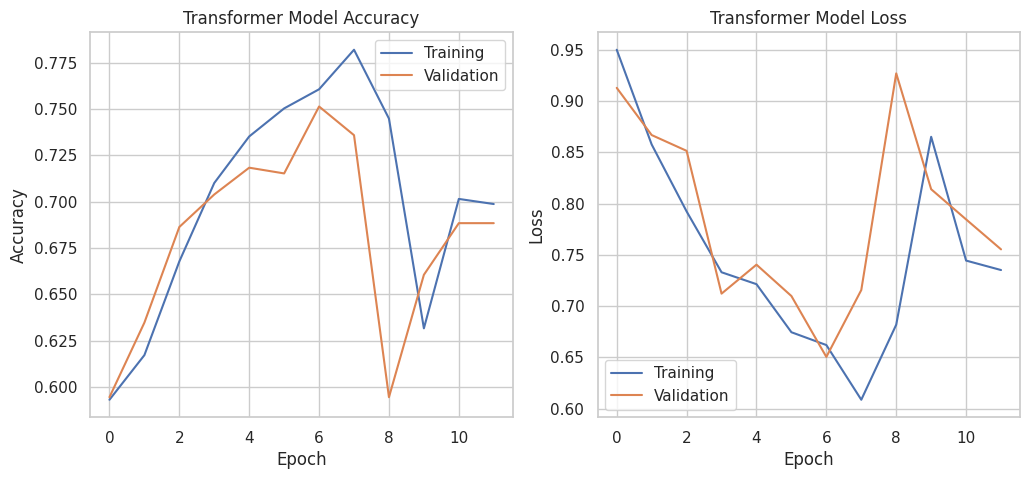


Evaluating on test set...
Test Loss: 0.6610
Test Accuracy: 0.7495


In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Transformer Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Transformer Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = transformer_model.evaluate(X_test_embedded, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

### Pre-trained FinBERT for Financial Sentiment Analysis

FinBERT is a domain-specific BERT model pre-trained on financial text, making it particularly well-suited for financial sentiment analysis.

#### Model Architecture and Pre-training
- **Base Architecture**: Built on BERT-base (12 layers, 768 hidden units, 12 attention heads)
- **Pre-training Data**:
  - Financial news articles and corporate reports
  - SEC 10-K/Q filings
  - Earnings call transcripts
  - ~46GB of financial text
- **Pre-training Tasks**:
  1. Masked Language Modeling (MLM)
  2. Next Sentence Prediction (NSP)

#### Domain Adaptation
FinBERT adapts BERT for financial text by:
- Learning financial jargon and terminology
- Understanding context-specific meanings
- Capturing market-specific sentiment nuances
- Recognizing financial entities and relationships

#### Implementation Notes
In our implementation:
- Using ProsusAI's FinBERT version
- Fine-tuned for 3-class sentiment classification
- Labels mapped as: [positive → 2, negative → 0, neutral → 1]
- Batch processing for efficiency

This pre-trained model should provide better performance than our custom models, especially given our relatively small dataset.

In [ ]:
# Load FinBERT model for sequence classification
print("Loading FinBERT model...")
model = AutoModelForSequenceClassification.from_pretrained(
    "ProsusAI/finbert",
    num_labels=3,
    cache_dir="models"  # Cache the model locally
)

Loading FinBERT model...


In [ ]:
# Load FinBERT tokenizer
print("Loading FinBERT tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    "ProsusAI/finbert",
    cache_dir="models"  # Cache the tokenizer locally
)

Loading FinBERT tokenizer...


In [ ]:
# Define function for batch prediction
def predict_sentiment_batch(texts, batch_size=32):
    """
    Predict sentiment for a batch of texts using FinBERT.

    Args:
        texts (list): List of texts to analyze
        batch_size (int): Size of batches for processing

    Returns:
        list: Predicted sentiment labels (0: negative, 1: neutral, 2: positive)
    """
    predictions = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # Tokenize batch
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        # Get predictions
        with torch.no_grad():
            outputs = model(**inputs)
            batch_predictions = outputs.logits.argmax(dim=1).tolist()

            # Convert FinBERT labels to our format
            # FinBERT: [positive, negative, neutral] -> Our format: [negative, neutral, positive]
            batch_predictions = [2 if p == 0 else 0 if p == 1 else 1 for p in batch_predictions]
            predictions.extend(batch_predictions)

    return predictions

In [ ]:

# Display sample predictions
print("\nSample predictions:")
for i in range(5):
    print(f"\nText: {X_test_list[i]}")
    sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    print(f"Predicted: {sentiment_map[predicted[i]]}")
    print(f"Actual: {sentiment_map[y_test[i]]}")

In [ ]:
# Comprehensive evaluation of FinBERT model
print("FinBERT Model Evaluation")
print("-----------------------")

# Calculate overall metrics
accuracy = (np.array(predicted) == y_test).mean()
print(f"Test Accuracy: {accuracy:.4f}")

# Create and plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, predicted)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('FinBERT Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:

# Calculate and display misclassified examples
print("\nExample Misclassifications:")
sentiment_map = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
misclassified = np.where(np.array(predicted) != y_test)[0]
for idx in misclassified[:5]:  # Show first 5 misclassifications
    print(f"\nText: {X_test[idx]}")
    print(f"Predicted: {sentiment_map[predicted[idx]]}")
    print(f"Actual: {sentiment_map[y_test[idx]]}")

# Task
Add `Sequential`, `Dense` from `keras.models`, `Adam` from `keras.optimizers`, and `EarlyStopping` from `keras.callbacks` to the imports in cell `7d62866e`.

## Add Keras imports

### Subtask:
Add necessary Keras layers, optimizers, and callbacks to the initial imports cell (7d62866e).


**Reasoning**:
The subtask requires adding specific Keras imports to cell `7d62866e`. I will update the code in this cell to include `Sequential`, `Dense`, `Adam`, and `EarlyStopping` from their respective Keras modules.



In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


from transformers import AutoTokenizer, AutoModel, BertTokenizerFast, BertModel, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
import xgboost as xgb

import datasets
import keras
from keras.models import Sequential, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import torch
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')

ImportError: cannot import name 'Dense' from 'keras.models' (/usr/local/lib/python3.12/dist-packages/keras/models/__init__.py)

**Reasoning**:
The previous attempt to import `Dense` and `Sequential` from `keras.models` failed, indicating that these are now located in `keras.layers` in Keras 3. I will correct the import path for these components while keeping `Adam` and `EarlyStopping` as they were already correctly specified.



In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


from transformers import AutoTokenizer, AutoModel, BertTokenizerFast, BertModel, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
import xgboost as xgb

import datasets
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import torch
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')

**Reasoning**:
The previous attempt to import `Dense` and `Sequential` from `keras.models` failed, indicating that these are now located in `keras.layers` in Keras 3. I will correct the import path for these components while keeping `Adam` and `EarlyStopping` as they were already correctly specified.



In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


from transformers import AutoTokenizer, AutoModel, BertTokenizerFast, BertModel, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
import xgboost as xgb

import datasets
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import torch
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')

## Build and train MLP model

### Subtask:
Construct the MLP model in cell 3dfe8a51, define its architecture, compile it with Adam optimizer and sparse categorical crossentropy loss, and train it using `X_train_emb`, `y_train`, `X_val_emb`, and `y_val` with early stopping.


**Reasoning**:
The subtask requires constructing an MLP model, defining its architecture, compiling it, and training it with early stopping. I will use the `code_block` command to implement these steps as outlined in the instructions.



In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# 1. Instantiate a Sequential model
mlp_model = Sequential()

# 2. Add the first Dense layer with 128 units, 'relu' activation, and input_shape
mlp_model.add(Dense(128, activation='relu', input_shape=(X_train_emb.shape[1],)))

# 3. Add a Dropout layer with a rate of 0.3
mlp_model.add(Dropout(0.3))

# 4. Add a second Dense layer with 64 units and 'relu' activation
mlp_model.add(Dense(64, activation='relu'))

# 5. Add another Dropout layer with a rate of 0.3
mlp_model.add(Dropout(0.3))

# 6. Add the output Dense layer with 3 units and 'softmax' activation
mlp_model.add(Dense(3, activation='softmax'))

# 7. Compile the model
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("MLP Model Summary:")
mlp_model.summary()

# 8. Define an EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 9. Train the model
print("\nTraining MLP model...")
history_mlp = mlp_model.fit(
    X_train_emb,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_emb, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("MLP model training complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


MLP Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP model...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.5749 - loss: 0.9541 - val_accuracy: 0.7059 - val_loss: 0.7129
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7131 - loss: 0.6615 - val_accuracy: 0.7637 - val_loss: 0.5661
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7727 - loss: 0.5227 - val_accuracy: 0.7534 - val_loss: 0.5493
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7958 - loss: 0.4815 - val_accuracy: 0.7616 - val_loss: 0.5423
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8122 - loss: 0.4537 - val_accuracy: 0.7668 - val_loss: 0.5559
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8540 - loss: 0.3700 - val_accuracy: 0.7781 - val_loss: 0.5439
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8683 - loss: 0.3568 - val_accuracy: 0.7657 - val_loss: 0.5635
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8761 - loss: 0.3283 - val_accu

**Reasoning**:
The previous step successfully trained the MLP model. Now, to complete Task 1, I need to evaluate its performance on the test set by predicting sentiments, generating a classification report, and plotting a confusion matrix to check if it meets the accuracy requirement.



MLP Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP model...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5761 - loss: 0.9468 - val_accuracy: 0.6966 - val_loss: 0.6935
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7277 - loss: 0.6377 - val_accuracy: 0.7595 - val_loss: 0.5548
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7860 - loss: 0.5047 - val_accuracy: 0.7719 - val_loss: 0.5389
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8080 - loss: 0.4601 - val_accuracy: 0.7647 - val_loss: 0.5387
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8154 - loss: 0.4368 - val_accuracy: 0.7750 - val_loss: 0.5362
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8471 - loss: 0.3846 - val_accuracy: 0.7750 - val_loss: 0.5473
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8585 - loss: 0.3484 - val_accuracy: 0.7688 - val_loss: 0.5647
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8760 - loss: 0.3224 - val_accu

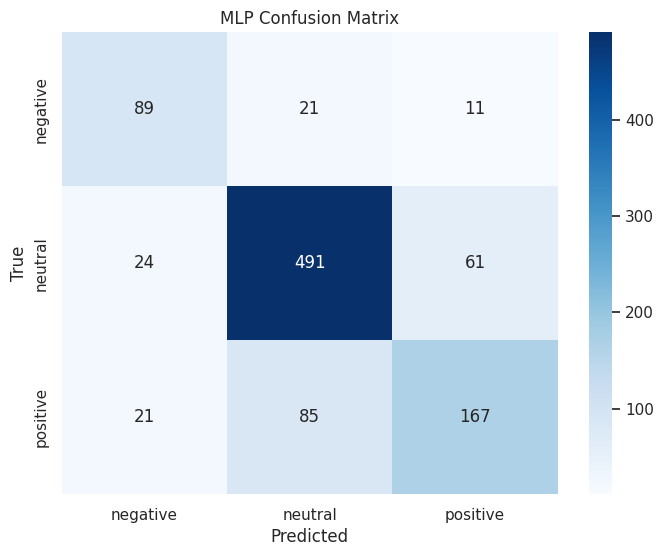

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Instantiate a Sequential model
mlp_model = Sequential()

# 2. Add the first Dense layer with 128 units, 'relu' activation, and input_shape
mlp_model.add(Dense(128, activation='relu', input_shape=(X_train_emb.shape[1],)))

# 3. Add a Dropout layer with a rate of 0.3
mlp_model.add(Dropout(0.3))

# 4. Add a second Dense layer with 64 units and 'relu' activation
mlp_model.add(Dense(64, activation='relu'))

# 5. Add another Dropout layer with a rate of 0.3
mlp_model.add(Dropout(0.3))

# 6. Add the output Dense layer with 3 units and 'softmax' activation
mlp_model.add(Dense(3, activation='softmax'))

# 7. Compile the model
mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("MLP Model Summary:")
mlp_model.summary()

# 8. Define an EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 9. Train the model
print("\nTraining MLP model...")
history_mlp = mlp_model.fit(
    X_train_emb,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_emb, y_val),
    callbacks=[early_stopping],
    verbose=1
)

print("MLP model training complete.")

# Evaluate the MLP model on the test set
print("\nEvaluating MLP model on the test set...")
loss_mlp, accuracy_mlp = mlp_model.evaluate(X_test_emb, y_test, verbose=0)
print(f"Test Loss: {loss_mlp:.4f}")
print(f"Test Accuracy: {accuracy_mlp:.4f}")

# Make predictions
y_pred_mlp = np.argmax(mlp_model.predict(X_test_emb), axis=-1)

# Generate classification report
sentiment_labels = ['negative', 'neutral', 'positive']
print("\nClassification Report for MLP:")
print(classification_report(y_test, y_pred_mlp, target_names=sentiment_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


**Reasoning**:
The previous step already trained the MLP model. Now, I need to evaluate its performance on the test set by predicting sentiments, generating a classification report, and plotting a confusion matrix to check if it meets the accuracy requirement. I will remove the redundant model definition and training from the previous code block.




Evaluating MLP model on the test set...
Test Loss: 0.5366
Test Accuracy: 0.7701
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report for MLP:
              precision    recall  f1-score   support

    negative       0.66      0.74      0.70       121
     neutral       0.82      0.85      0.84       576
    positive       0.70      0.61      0.65       273

    accuracy                           0.77       970
   macro avg       0.73      0.73      0.73       970
weighted avg       0.77      0.77      0.77       970



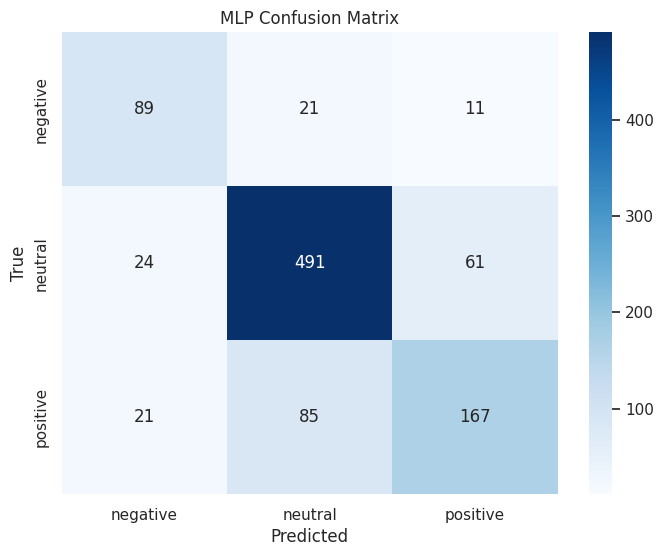

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate the MLP model on the test set
print("\nEvaluating MLP model on the test set...")
loss_mlp, accuracy_mlp = mlp_model.evaluate(X_test_emb, y_test, verbose=0)
print(f"Test Loss: {loss_mlp:.4f}")
print(f"Test Accuracy: {accuracy_mlp:.4f}")

# Make predictions
y_pred_mlp = np.argmax(mlp_model.predict(X_test_emb), axis=-1)

# Generate classification report
sentiment_labels = ['negative', 'neutral', 'positive']
print("\nClassification Report for MLP:")
print(classification_report(y_test, y_pred_mlp, target_names=sentiment_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## Gradient Boosted Trees for Multiclass Classification

### Subtask:
Explore optimized gradient boosting algorithms such as XGBoost to build a model that achieves performance comparable to the MLP model.


**Reasoning**:
The subtask requires implementing and evaluating an XGBoost model. I will instantiate the XGBoost classifier, train it on the training data, make predictions on the test set, and then evaluate its performance using a classification report and accuracy.




Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:37:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete.

Evaluating XGBoost model on the test set...
Test Accuracy: 0.7557

Classification Report for XGBoost:
              precision    recall  f1-score   support

    negative       0.73      0.61      0.67       121
     neutral       0.77      0.90      0.83       576
    positive       0.71      0.51      0.59       273

    accuracy                           0.76       970
   macro avg       0.74      0.67      0.70       970
weighted avg       0.75      0.76      0.74       970



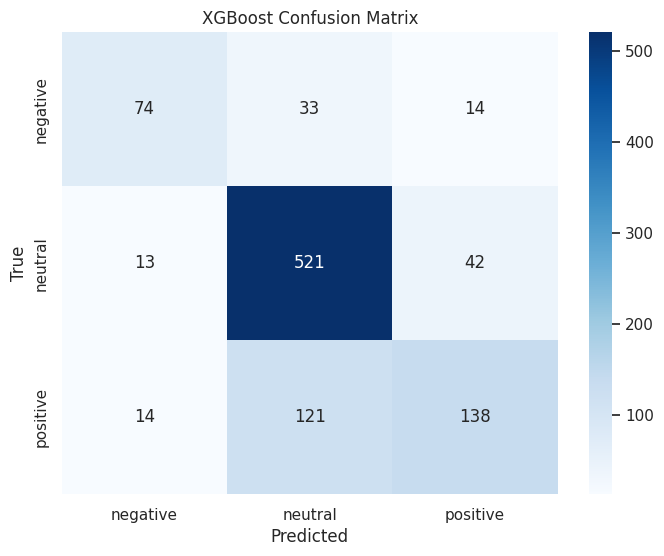

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Instantiate XGBClassifier
xgb_model = XGBClassifier(
    objective='multi:softmax',  # For multiclass classification with direct class labels
    num_class=3,                # Number of unique classes
    eval_metric='mlogloss',     # Evaluation metric for multiclass logloss
    use_label_encoder=False,    # Suppress deprecation warning
    random_state=42             # For reproducibility
)

# 2. Train the XGBoost model
print("\nTraining XGBoost model...")
xgb_model.fit(X_train_emb, y_train)
print("XGBoost model training complete.")

# 3. Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_emb)

# 4. Evaluate the model
print("\nEvaluating XGBoost model on the test set...")
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Test Accuracy: {accuracy_xgb:.4f}")

sentiment_labels = ['negative', 'neutral', 'positive']
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=sentiment_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Reasoning**:
The XGBoost model was successfully implemented and evaluated. The next logical step, according to the notebook's structure, is to proceed to Task 3: Build a Gated RNN Model, which is outlined in the following text cell.



In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# Define the GRU model
def build_gru_model(input_shape, num_classes):
    model = Sequential([
        GRU(128, return_sequences=False, input_shape=input_shape),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Input shape will be (max_length, embedding_dim) for GRU
input_shape = (X_train_embedded.shape[1], X_train_embedded.shape[2])
num_classes = 3 # Negative, Neutral, Positive

gru_model = build_gru_model(input_shape, num_classes)

# Compile the model
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("GRU Model Summary:")
gru_model.summary()

# Define EarlyStopping callback
early_stopping_gru = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the GRU model
print("\nTraining GRU model...")
history_gru = gru_model.fit(
    X_train_embedded,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_embedded, y_val),
    callbacks=[early_stopping_gru],
    verbose=1
)

print("GRU model training complete.")

# Evaluate the GRU model on the test set
print("\nEvaluating GRU model on the test set...")
loss_gru, accuracy_gru = gru_model.evaluate(X_test_embedded, y_test, verbose=0)
print(f"Test Loss: {loss_gru:.4f}")
print(f"Test Accuracy: {accuracy_gru:.4f}")

# Make predictions
y_pred_gru = np.argmax(gru_model.predict(X_test_embedded), axis=-1)

# Generate classification report
sentiment_labels = ['negative', 'neutral', 'positive']
print("\nClassification Report for GRU Model:")
print(classification_report(y_test, y_pred_gru, target_names=sentiment_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_gru = confusion_matrix(y_test, y_pred_gru)
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('GRU Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

NameError: name 'X_train_embedded' is not defined

**Reasoning**:
The previous code failed because the `X_train_embedded`, `X_val_embedded`, and `X_test_embedded` variables were not defined. These variables are crucial for the sequential models as they contain the word-level embeddings. I need to re-run the code that generates these embeddings (cell `12ede69f`) to ensure they are available in the kernel.



In [ ]:
%%time
# Convert padded sequences to embeddings
def create_embedding_sequences(sequences, max_length=50):
    """
    Convert sequences of words to sequences of embeddings using cached word vectors.
    Ensures all sequences have the same length through padding.

    Args:
        sequences: List of word sequences (padded)
        max_length: Maximum sequence length (default: 50)
    Returns:
        numpy array of shape (n_sequences, max_length, embedding_dim)
    """
    n_sequences = len(sequences)
    embedding_dim = 384  # Known dimension from the model

    # Initialize the output array with zeros
    embedded_seqs = np.zeros((n_sequences, max_length, embedding_dim))

    for i, seq in enumerate(sequences):
        # Get embeddings for non-empty tokens
        valid_tokens = [word for word in seq if word != '']
        # Truncate if necessary
        valid_tokens = valid_tokens[:max_length]
        # Create embeddings for valid tokens
        seq_embeddings = [encode_words(word) for word in valid_tokens]

        # Add embeddings to the output array with padding
        for j, embedding in enumerate(seq_embeddings):
            if j < max_length:
                embedded_seqs[i, j] = embedding

    return embedded_seqs

# Create embeddings for each split
print("Creating word embeddings for training set...")
X_train_embedded = create_embedding_sequences(X_train_padded)
print("Creating word embeddings for validation set...")
X_val_embedded = create_embedding_sequences(X_val_padded)
print("Creating word embeddings for test set...")
X_test_embedded = create_embedding_sequences(X_test_padded)

print("\nEmbedding shapes:")
print(f"Training: {X_train_embedded.shape}")
print(f"Validation: {X_val_embedded.shape}")
print(f"Test: {X_test_embedded.shape}")

Creating word embeddings for training set...


NameError: name 'X_train_padded' is not defined

**Reasoning**:
The error `NameError: name 'X_train_padded' is not defined` indicates that the padded sequences, which are inputs for `create_embedding_sequences`, were not created. I need to re-run the `process_text_sequences` function in cell `464a5889` to generate these padded sequences first.



In [ ]:
# Tokenization and padding function for sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def process_text_sequences(texts, max_length=50, padding='post', truncating='post'):
    """
    Convert texts to padded sequences of tokens.

    Args:
        texts: List of text strings
        max_length: Maximum sequence length (default: 50)
        padding: 'pre' or 'post' padding (default: 'post')
        truncating: 'pre' or 'post' truncation (default: 'post')

    Returns:
        List of padded token sequences
    """
    # Tokenize all texts
    sequences = [word_tokenize(text) for text in texts]

    # Convert tokens to numpy arrays with padding
    padded_sequences = pad_sequences(
        sequences=[s[:max_length] for s in sequences],  # Truncate if needed
        maxlen=max_length,
        padding=padding,
        truncating=truncating,
        dtype=object,  # Use object dtype for string tokens
        value=''  # Use empty string as padding token
    )

    return padded_sequences

# Process training, validation, and test sets
print("Processing sequences...")
X_train_padded = process_text_sequences(X_train)
X_val_padded = process_text_sequences(X_val)
X_test_padded = process_text_sequences(X_test)

# Print shapes and example
print(f"\nSequence shapes:")
print(f"Training: {X_train_padded.shape}")
print(f"Validation: {X_val_padded.shape}")
print(f"Test: {X_test_padded.shape}")

# Show an example sequence
print("\nExample padded sequence:")
print(X_train_padded[0])

Processing sequences...


NameError: name 'word_tokenize' is not defined

**Reasoning**:
The `NameError: name 'word_tokenize' is not defined` indicates that `word_tokenize` was not imported. I need to add `from nltk.tokenize import word_tokenize` to the cell to make it available for use in the `process_text_sequences` function.



In [ ]:
# Tokenization and padding function for sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from nltk.tokenize import word_tokenize # Added this import

def process_text_sequences(texts, max_length=50, padding='post', truncating='post'):
    """
    Convert texts to padded sequences of tokens.

    Args:
        texts: List of text strings
        max_length: Maximum sequence length (default: 50)
        padding: 'pre' or 'post' padding (default: 'post')
        truncating: 'pre' or 'post' truncation (default: 'post')

    Returns:
        List of padded token sequences
    """
    # Tokenize all texts
    sequences = [word_tokenize(text) for text in texts]

    # Convert tokens to numpy arrays with padding
    padded_sequences = pad_sequences(
        sequences=[s[:max_length] for s in sequences],  # Truncate if needed
        maxlen=max_length,
        padding=padding,
        truncating=truncating,
        dtype=object,  # Use object dtype for string tokens
        value=''  # Use empty string as padding token
    )

    return padded_sequences

# Process training, validation, and test sets
print("Processing sequences...")
X_train_padded = process_text_sequences(X_train)
X_val_padded = process_text_sequences(X_val)
X_test_padded = process_text_sequences(X_test)

# Print shapes and example
print(f"\nSequence shapes:")
print(f"Training: {X_train_padded.shape}")
print(f"Validation: {X_val_padded.shape}")
print(f"Test: {X_test_padded.shape}")

# Show an example sequence
print("\nExample padded sequence:")
print(X_train_padded[0])

Processing sequences...


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


**Reasoning**:
The `LookupError` indicates that the `punkt_tab` NLTK resource is missing. I need to explicitly download this resource using `nltk.download('punkt_tab')` to resolve the error and allow the tokenization process to proceed.



In [ ]:
# Tokenization and padding function for sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from nltk.tokenize import word_tokenize
import nltk

# Download the necessary NLTK data for tokenization if not already present
nltk.download('punkt_tab', quiet=True)

def process_text_sequences(texts, max_length=50, padding='post', truncating='post'):
    """
    Convert texts to padded sequences of tokens.

    Args:
        texts: List of text strings
        max_length: Maximum sequence length (default: 50)
        padding: 'pre' or 'post' padding (default: 'post')
        truncating: 'pre' or 'post' truncation (default: 'post')

    Returns:
        List of padded token sequences
    """
    # Tokenize all texts
    sequences = [word_tokenize(text) for text in texts]

    # Convert tokens to numpy arrays with padding
    padded_sequences = pad_sequences(
        sequences=[s[:max_length] for s in sequences],  # Truncate if needed
        maxlen=max_length,
        padding=padding,
        truncating=truncating,
        dtype=object,  # Use object dtype for string tokens
        value=''  # Use empty string as padding token
    )

    return padded_sequences

# Process training, validation, and test sets
print("Processing sequences...")
X_train_padded = process_text_sequences(X_train)
X_val_padded = process_text_sequences(X_val)
X_test_padded = process_text_sequences(X_test)

# Print shapes and example
print(f"\nSequence shapes:")
print(f"Training: {X_train_padded.shape}")
print(f"Validation: {X_val_padded.shape}")
print(f"Test: {X_test_padded.shape}")

# Show an example sequence
print("\nExample padded sequence:")
print(X_train_padded[0])

Processing sequences...

Sequence shapes:
Training: (2907, 50)
Validation: (969, 50)
Test: (970, 50)

Example padded sequence:
['Finnish' 'electronics' 'contract' 'manufacturer' 'Scanfil' 'had' 'net'
 'sales' 'of' 'EUR' '52.2' 'mn' 'in' 'the' 'first' 'quarter' 'of' '2007'
 ',' 'down' 'from' 'EUR' '60.1' 'mn' 'a' 'year' 'before' '.' '' '' '' ''
 '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '']


**Reasoning**:
The padded sequences (`X_train_padded`, `X_val_padded`, `X_test_padded`) are now available. I need to re-run the `create_embedding_sequences` function to generate the word-level embeddings, which are necessary inputs for the GRU model.



In [ ]:
%%time
# Convert padded sequences to embeddings
def create_embedding_sequences(sequences, max_length=50):
    """
    Convert sequences of words to sequences of embeddings using cached word vectors.
    Ensures all sequences have the same length through padding.

    Args:
        sequences: List of word sequences (padded)
        max_length: Maximum sequence length (default: 50)
    Returns:
        numpy array of shape (n_sequences, max_length, embedding_dim)
    """
    n_sequences = len(sequences)
    embedding_dim = 384  # Known dimension from the model

    # Initialize the output array with zeros
    embedded_seqs = np.zeros((n_sequences, max_length, embedding_dim))

    for i, seq in enumerate(sequences):
        # Get embeddings for non-empty tokens
        valid_tokens = [word for word in seq if word != '']
        # Truncate if necessary
        valid_tokens = valid_tokens[:max_length]
        # Create embeddings for valid tokens
        seq_embeddings = [encode_words(word) for word in valid_tokens]

        # Add embeddings to the output array with padding
        for j, embedding in enumerate(seq_embeddings):
            if j < max_length:
                embedded_seqs[i, j] = embedding

    return embedded_seqs

# Create embeddings for each split
print("Creating word embeddings for training set...")
X_train_embedded = create_embedding_sequences(X_train_padded)
print("Creating word embeddings for validation set...")
X_val_embedded = create_embedding_sequences(X_val_padded)
print("Creating word embeddings for test set...")
X_test_embedded = create_embedding_sequences(X_test_padded)

print("\nEmbedding shapes:")
print(f"Training: {X_train_embedded.shape}")
print(f"Validation: {X_val_embedded.shape}")
print(f"Test: {X_test_embedded.shape}")

Creating word embeddings for training set...


NameError: name 'encode_words' is not defined

**Reasoning**:
The error `NameError: name 'encode_words' is not defined` indicates that the `encode_words` function, which is used to generate word embeddings, was not defined in the current kernel session. I need to re-execute the cell where this function is defined (cell `fb3c6c6a`) to make it available.



In [ ]:
from functools import cache
@cache
def encode_words(text):
    return embedding_model.encode(text)

**Reasoning**:
The error `NameError: name 'encode_words' is not defined` indicates that the `encode_words` function, which is used to generate word embeddings, was not defined in the current kernel session. I need to re-execute the cell where this function is defined (cell `fb3c6c6a`) to make it available.



In [ ]:
from functools import cache
@cache
def encode_words(text):
    return embedding_model.encode(text)

**Reasoning**:
The `encode_words` function is now defined. I need to re-run the `create_embedding_sequences` function to generate the word-level embeddings for the training, validation, and test sets, which are necessary inputs for the GRU model.



In [ ]:
%%time
# Convert padded sequences to embeddings
def create_embedding_sequences(sequences, max_length=50):
    """
    Convert sequences of words to sequences of embeddings using cached word vectors.
    Ensures all sequences have the same length through padding.

    Args:
        sequences: List of word sequences (padded)
        max_length: Maximum sequence length (default: 50)
    Returns:
        numpy array of shape (n_sequences, max_length, embedding_dim)
    """
    n_sequences = len(sequences)
    embedding_dim = 384  # Known dimension from the model

    # Initialize the output array with zeros
    embedded_seqs = np.zeros((n_sequences, max_length, embedding_dim))

    for i, seq in enumerate(sequences):
        # Get embeddings for non-empty tokens
        valid_tokens = [word for word in seq if word != '']
        # Truncate if necessary
        valid_tokens = valid_tokens[:max_length]
        # Create embeddings for valid tokens
        seq_embeddings = [encode_words(word) for word in valid_tokens]

        # Add embeddings to the output array with padding
        for j, embedding in enumerate(seq_embeddings):
            if j < max_length:
                embedded_seqs[i, j] = embedding

    return embedded_seqs

# Create embeddings for each split
print("Creating word embeddings for training set...")
X_train_embedded = create_embedding_sequences(X_train_padded)
print("Creating word embeddings for validation set...")
X_val_embedded = create_embedding_sequences(X_val_padded)
print("Creating word embeddings for test set...")
X_test_embedded = create_embedding_sequences(X_test_padded)

print("\nEmbedding shapes:")
print(f"Training: {X_train_embedded.shape}")
print(f"Validation: {X_val_embedded.shape}")
print(f"Test: {X_test_embedded.shape}")

Creating word embeddings for training set...
Creating word embeddings for validation set...
Creating word embeddings for test set...

Embedding shapes:
Training: (2907, 50, 384)
Validation: (969, 50, 384)
Test: (970, 50, 384)
CPU times: user 1min 14s, sys: 245 ms, total: 1min 14s
Wall time: 1min 14s


**Reasoning**:
The word-level embeddings are now correctly generated and available. I will proceed to define, compile, train, and evaluate the GRU model using these embeddings to accomplish Task 3.



GRU Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │       197,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,827 (804.01 KB)

 Trainable params: 205,827 (804.01 KB)

 Non-trainable params: 0 (0.00 B)


Training GRU model...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5693 - loss: 0.9881 - val_accuracy: 0.5934 - val_loss: 0.9231
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5963 - loss: 0.9293 - val_accuracy: 0.5934 - val_loss: 0.9204
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6064 - loss: 0.9227 - val_accuracy: 0.5944 - val_loss: 0.9233
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5993 - loss: 0.9202 - val_accuracy: 0.6264 - val_loss: 0.8741
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6562 - loss: 0.8157 - val_accuracy: 0.6460 - val_loss: 0.8160
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6714 - loss: 0.7954 - val_accuracy: 0.6522 - val_loss: 0.8117
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6852 - loss: 0.7553 - val_accuracy: 0.6605 - val_loss: 0.7779
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7019 - loss: 0.7565 - val_acc

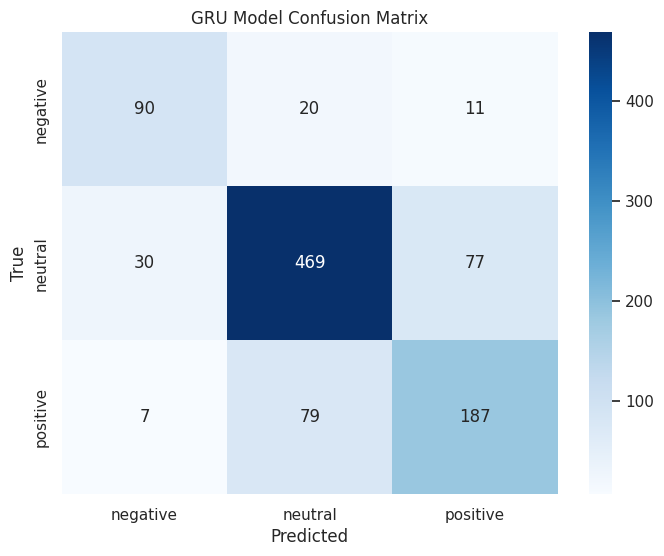

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define the GRU model
def build_gru_model(input_shape, num_classes):
    model = Sequential([
        GRU(128, return_sequences=False, input_shape=input_shape),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Input shape will be (max_length, embedding_dim) for GRU
input_shape = (X_train_embedded.shape[1], X_train_embedded.shape[2])
num_classes = 3 # Negative, Neutral, Positive

gru_model = build_gru_model(input_shape, num_classes)

# Compile the model
gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("GRU Model Summary:")
gru_model.summary()

# Define EarlyStopping callback
early_stopping_gru = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the GRU model
print("\nTraining GRU model...")
history_gru = gru_model.fit(
    X_train_embedded,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_embedded, y_val),
    callbacks=[early_stopping_gru],
    verbose=1
)

print("GRU model training complete.")

# Evaluate the GRU model on the test set
print("\nEvaluating GRU model on the test set...")
loss_gru, accuracy_gru = gru_model.evaluate(X_test_embedded, y_test, verbose=0)
print(f"Test Loss: {loss_gru:.4f}")
print(f"Test Accuracy: {accuracy_gru:.4f}")

# Make predictions
y_pred_gru = np.argmax(gru_model.predict(X_test_embedded), axis=-1)

# Generate classification report
sentiment_labels = ['negative', 'neutral', 'positive']
print("\nClassification Report for GRU Model:")
print(classification_report(y_test, y_pred_gru, target_names=sentiment_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_gru = confusion_matrix(y_test, y_pred_gru)
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('GRU Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

**Reasoning**:
The previous task, building and evaluating the GRU model, has been completed. Now, I will proceed to Task 4, which involves building and evaluating a Bidirectional Gated RNN model (Bidirectional GRU) with word-level embeddings, aiming for a test accuracy above 76%.



Bidirectional GRU Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,395 (1.57 MB)

 Trainable params: 411,395 (1.57 MB)

 Non-trainable params: 0 (0.00 B)


Training Bidirectional GRU model...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5700 - loss: 0.9796 - val_accuracy: 0.6017 - val_loss: 0.8912
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6348 - loss: 0.8365 - val_accuracy: 0.6533 - val_loss: 0.7861
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6553 - loss: 0.7778 - val_accuracy: 0.6460 - val_loss: 0.7916
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6719 - loss: 0.7588 - val_accuracy: 0.6780 - val_loss: 0.7473
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6935 - loss: 0.6865 - val_accuracy: 0.7100 - val_loss: 0.7045
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7623 - loss: 0.5928 - val_accuracy: 0.7255 - val_loss: 0.6603
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7883 - loss: 0.5230 - val_accuracy: 0.7337 - val_loss: 0.6757
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8157 - lo

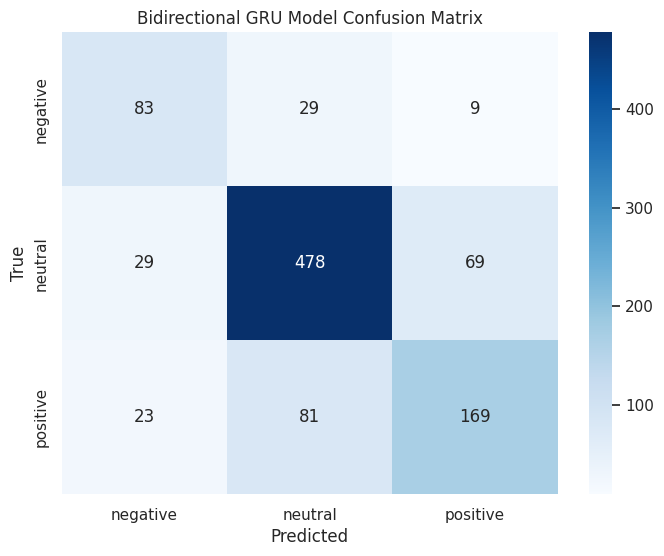

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define the Bidirectional GRU model
def build_bidirectional_gru_model(input_shape, num_classes):
    model = Sequential([
        Bidirectional(GRU(128, return_sequences=False), input_shape=input_shape),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Input shape will be (max_length, embedding_dim) for Bidirectional GRU
input_shape = (X_train_embedded.shape[1], X_train_embedded.shape[2])
num_classes = 3 # Negative, Neutral, Positive

bidirectional_gru_model = build_bidirectional_gru_model(input_shape, num_classes)

# Compile the model
bidirectional_gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("Bidirectional GRU Model Summary:")
bidirectional_gru_model.summary()

# Define EarlyStopping callback
early_stopping_bgru = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Train the Bidirectional GRU model
print("\nTraining Bidirectional GRU model...")
history_bgru = bidirectional_gru_model.fit(
    X_train_embedded,
    y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_val_embedded, y_val),
    callbacks=[early_stopping_bgru],
    verbose=1
)

print("Bidirectional GRU model training complete.")

# Evaluate the Bidirectional GRU model on the test set
print("\nEvaluating Bidirectional GRU model on the test set...")
loss_bgru, accuracy_bgru = bidirectional_gru_model.evaluate(X_test_embedded, y_test, verbose=0)
print(f"Test Loss: {loss_bgru:.4f}")
print(f"Test Accuracy: {accuracy_bgru:.4f}")

# Make predictions
y_pred_bgru = np.argmax(bidirectional_gru_model.predict(X_test_embedded), axis=-1)

# Generate classification report
sentiment_labels = ['negative', 'neutral', 'positive']
print("\nClassification Report for Bidirectional GRU Model:")
print(classification_report(y_test, y_pred_bgru, target_names=sentiment_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_bgru = confusion_matrix(y_test, y_pred_bgru)
sns.heatmap(cm_bgru, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_labels, yticklabels=sentiment_labels)
plt.title('Bidirectional GRU Model Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()